# Práctica 3: Análisis y Visualización de Datos Clínicos
**Programa de Preparación CERN 2026 — Semana 2**

En este cuaderno exploramos los datos de inflamación del ensayo clínico (`data/inflammation-01.csv`) aplicando **NumPy** y **Matplotlib**.

### 1. Importar librerías y cargar datos

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar la matriz de datos desde data/inflammation-01.csv
data = np.loadtxt(fname='data/inflammation-01.csv', delimiter=',')

print("Tipo de objeto:", type(data))
print("Forma de la matriz (pacientes, días):", data.shape)
print("Tipo de datos interno:", data.dtype)

Tipo de objeto: <class 'numpy.ndarray'>
Forma de la matriz (pacientes, días): (60, 40)
Tipo de datos interno: float64


### 2. Exploración y Slicing (Rebanado 2D)
Inspeccionemos valores puntuales y rebanadas de la matriz.

In [25]:
# Primer paciente, primer día
print("Primer valor [0, 0]:", data[0, 0])

# Paciente 30, día 20
print("Valor central [30, 20]:", data[30, 20])

# Primeros 3 pacientes, primeros 5 días
print("\nPrimeros 3 pacientes (primeros 5 días):\n", data[0:3, 0:5])

Primer valor [0, 0]: 0.0
Valor central [30, 20]: 13.0

Primeros 3 pacientes (primeros 5 días):
 [[0. 0. 1. 3. 1.]
 [0. 1. 2. 1. 2.]
 [0. 1. 1. 3. 3.]]


### 3. Operaciones por Ejes (La prensa hidráulica: `axis=0` vs `axis=1`)

In [26]:
# Promedio diario evaluando a TODOS los pacientes (aplastar pacientes: axis=0)
promedio_diario = np.mean(data, axis=0)
print("Cantidad de promedios diarios (debe ser 40):", promedio_diario.shape)

# Promedio de cada paciente evaluando TODOS sus 40 días (aplastar días: axis=1)
promedio_pacientes = np.mean(data, axis=1)
print("Cantidad de promedios por paciente (debe ser 60):", promedio_pacientes.shape)

Cantidad de promedios diarios (debe ser 40): (40,)
Cantidad de promedios por paciente (debe ser 60): (60,)


### 4. Visualización: Mapa de Calor (Heatmap)

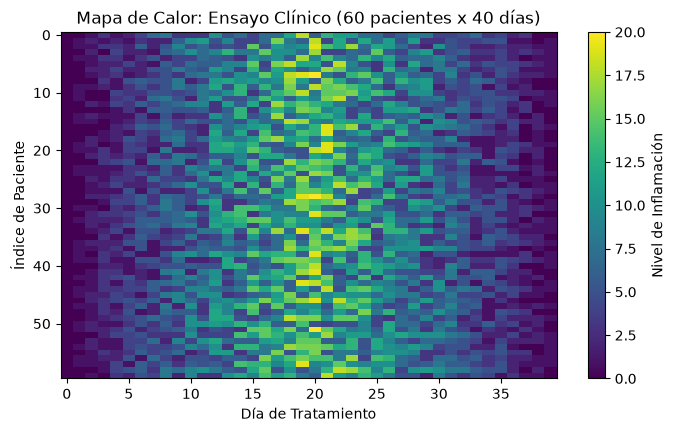

In [27]:
plt.figure(figsize=(8, 4.5))
plt.imshow(data, aspect='auto', cmap='viridis')
plt.colorbar(label='Nivel de Inflamación')
plt.title('Mapa de Calor: Ensayo Clínico (60 pacientes x 40 días)')
plt.xlabel('Día de Tratamiento')
plt.ylabel('Índice de Paciente')
plt.show()

### 5. Detección de Anomalías: Panel Múltiple (Subplots)

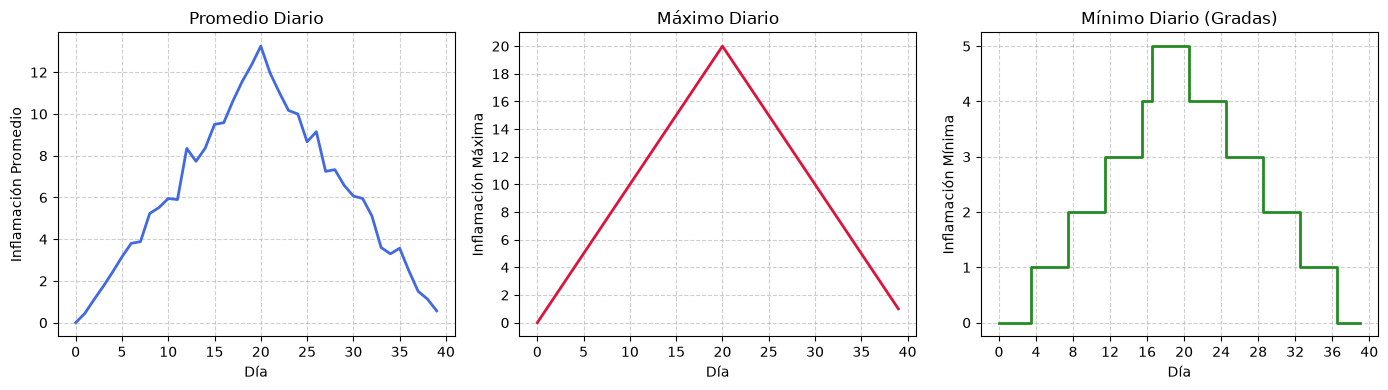

In [28]:
# Requisitos de Métodos Numéricos ESPE: Marcadores, Grilla Mayor/Menor, Título General y Etiqueta Final
fig = plt.figure(figsize=(15.0, 4.5))

# Título General ubicado en la parte superior izquierda
fig.suptitle('Evaluación Estadística de Inflamación — Archivo 01', x=0.05, y=0.98, ha='left', fontsize=13, weight='bold')

# 1. Subplot: Promedio Diario
axes1 = fig.add_subplot(1, 3, 1)
y1 = np.mean(data, axis=0)
axes1.plot(range(40), y1, linestyle='-', marker='o', markersize=3.5, color='royalblue', label='Promedio')
axes1.set_title('Promedio Diario', fontsize=11, weight='bold')
axes1.set_xlabel('Día de Tratamiento (Iteraciones)', fontsize=10)
axes1.set_ylabel('Nivel de Inflamación Promedio', fontsize=10)
axes1.set_xticks(np.arange(0, 41, 5))
axes1.minorticks_on()
axes1.grid(True, which='major', linestyle='-', alpha=0.6)
axes1.grid(True, which='minor', linestyle=':', alpha=0.3)
# Etiqueta en el último dato
axes1.annotate(f'Final: {y1[-1]:.2f}', xy=(39, y1[-1]), xytext=(27, y1[-1] + 2.5),
               arrowprops=dict(arrowstyle='->', color='navy', lw=1.2),
               bbox=dict(boxstyle='round,pad=0.2', fc='lightcyan', ec='royalblue', lw=1),
               fontsize=9, weight='bold')

# 2. Subplot: Máximo Diario
axes2 = fig.add_subplot(1, 3, 2)
y2 = np.max(data, axis=0)
axes2.plot(range(40), y2, linestyle='-', marker='s', markersize=3.5, color='crimson', label='Máximo')
axes2.set_title('Máximo Diario (Rampa)', fontsize=11, weight='bold')
axes2.set_xlabel('Día de Tratamiento (Iteraciones)', fontsize=10)
axes2.set_ylabel('Nivel de Inflamación Máxima', fontsize=10)
axes2.set_xticks(np.arange(0, 41, 5))
axes2.set_yticks(np.arange(0, 21, 2))
axes2.minorticks_on()
axes2.grid(True, which='major', linestyle='-', alpha=0.6)
axes2.grid(True, which='minor', linestyle=':', alpha=0.3)
# Etiqueta en el último dato
axes2.annotate(f'Final: {y2[-1]:.1f}', xy=(39, y2[-1]), xytext=(27, y2[-1] + 3.0),
               arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
               bbox=dict(boxstyle='round,pad=0.2', fc='mistyrose', ec='crimson', lw=1),
               fontsize=9, weight='bold')

# 3. Subplot: Mínimo Diario
axes3 = fig.add_subplot(1, 3, 3)
y3 = np.min(data, axis=0)
axes3.step(range(40), y3, where='mid', color='forestgreen', linewidth=1.5)
axes3.plot(range(40), y3, linestyle='none', marker='^', markersize=4, color='forestgreen')
axes3.set_title('Mínimo Diario (Gradas)', fontsize=11, weight='bold')
axes3.set_xlabel('Día de Tratamiento (Iteraciones)', fontsize=10)
axes3.set_ylabel('Nivel de Inflamación Mínima', fontsize=10)
axes3.set_xticks(np.arange(0, 41, 4))
axes3.set_yticks(np.arange(0, 6, 1))
axes3.minorticks_on()
axes3.grid(True, which='major', linestyle='-', alpha=0.6)
axes3.grid(True, which='minor', linestyle=':', alpha=0.3)
# Etiqueta en el último dato
axes3.annotate(f'Final: {y3[-1]:.1f}', xy=(39, y3[-1]), xytext=(27, y3[-1] + 1.2),
               arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.2),
               bbox=dict(boxstyle='round,pad=0.2', fc='honeydew', ec='forestgreen', lw=1),
               fontsize=9, weight='bold')

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 6. Funciones Modulares de Diagnóstico y Visualización
Empaquetamos la lógica en funciones reutilizables (`def`) para no repetir código.

In [29]:
import glob

def detectar_anomalias(data):
    """Revisa matemáticamente si los datos muestran signos de ser artificiales o erróneos."""
    max_diario = np.max(data, axis=0)
    min_diario = np.min(data, axis=0)
    
    if max_diario[0] == 0 and max_diario[20] == 20:
        print('  ⚠️ ALERTA: Los máximos forman una rampa lineal artificial.')
    elif np.sum(min_diario) == 0:
        print('  ⚠️ ALERTA: Mínimos en cero todos los días (posible sensor dañado).')
    else:
        print('  ✅ Los datos parecen biológicamente normales.')

def analizar(filename):
    """Carga un dataset, diagnostica anomalías y genera su panel triple con estándar ESPE."""
    print(f'\n========================================')
    print(f'PROCESANDO ARCHIVO: {filename}')
    print(f'========================================')
    
    data = np.loadtxt(fname=filename, delimiter=',')
    detectar_anomalias(data)
    
    fig = plt.figure(figsize=(15.0, 4.2))
    fig.suptitle(f'Estudio Clínico: {filename}', x=0.05, y=0.98, ha='left', fontsize=12, weight='bold')
    
    # 1. Promedio
    ax1 = fig.add_subplot(1, 3, 1)
    y1 = np.mean(data, axis=0)
    ax1.plot(range(40), y1, linestyle='-', marker='o', markersize=3, color='royalblue')
    ax1.set_title('Promedio Diario', fontsize=10, weight='bold')
    ax1.set_xlabel('Día de Tratamiento', fontsize=9)
    ax1.set_ylabel('Inflamación', fontsize=9)
    ax1.minorticks_on()
    ax1.grid(True, which='major', linestyle='-', alpha=0.5)
    ax1.grid(True, which='minor', linestyle=':', alpha=0.25)
    ax1.annotate(f'{y1[-1]:.2f}', xy=(39, y1[-1]), xytext=(30, y1[-1] + 2),
                 arrowprops=dict(arrowstyle='->', color='navy'),
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='royalblue', lw=0.8), fontsize=8)
    
    # 2. Máximo
    ax2 = fig.add_subplot(1, 3, 2)
    y2 = np.max(data, axis=0)
    ax2.plot(range(40), y2, linestyle='-', marker='s', markersize=3, color='crimson')
    ax2.set_title('Máximo Diario', fontsize=10, weight='bold')
    ax2.set_xlabel('Día de Tratamiento', fontsize=9)
    ax2.minorticks_on()
    ax2.grid(True, which='major', linestyle='-', alpha=0.5)
    ax2.grid(True, which='minor', linestyle=':', alpha=0.25)
    ax2.annotate(f'{y2[-1]:.1f}', xy=(39, y2[-1]), xytext=(30, y2[-1] + 3),
                 arrowprops=dict(arrowstyle='->', color='darkred'),
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='crimson', lw=0.8), fontsize=8)
    
    # 3. Mínimo
    ax3 = fig.add_subplot(1, 3, 3)
    y3 = np.min(data, axis=0)
    ax3.step(range(40), y3, where='mid', color='forestgreen')
    ax3.plot(range(40), y3, linestyle='none', marker='^', markersize=3.5, color='forestgreen')
    ax3.set_title('Mínimo Diario', fontsize=10, weight='bold')
    ax3.set_xlabel('Día de Tratamiento', fontsize=9)
    ax3.minorticks_on()
    ax3.grid(True, which='major', linestyle='-', alpha=0.5)
    ax3.grid(True, which='minor', linestyle=':', alpha=0.25)
    ax3.annotate(f'{y3[-1]:.1f}', xy=(39, y3[-1]), xytext=(30, y3[-1] + 1),
                 arrowprops=dict(arrowstyle='->', color='darkgreen'),
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='forestgreen', lw=0.8), fontsize=8)
    
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### 7. Automatización por Lotes con `glob`
Buscamos todos los archivos `data/inflammation-*.csv` y los procesamos automáticamente.

Total de archivos encontrados: 12

PROCESANDO ARCHIVO: data\inflammation-01.csv
  ⚠️ ALERTA: Los máximos forman una rampa lineal artificial.


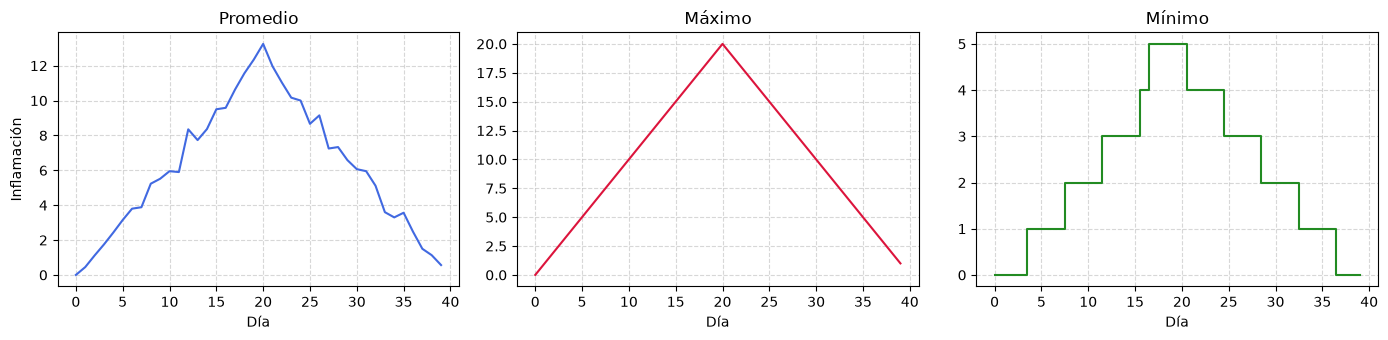


PROCESANDO ARCHIVO: data\inflammation-02.csv
  ⚠️ ALERTA: Los máximos forman una rampa lineal artificial.


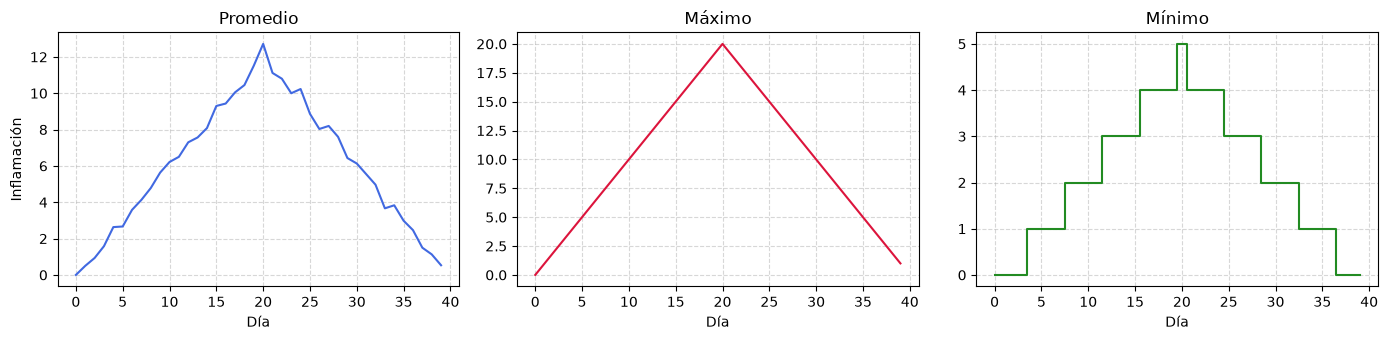


PROCESANDO ARCHIVO: data\inflammation-03.csv
  ⚠️ ALERTA: Mínimos en cero todos los días (posible sensor dañado).


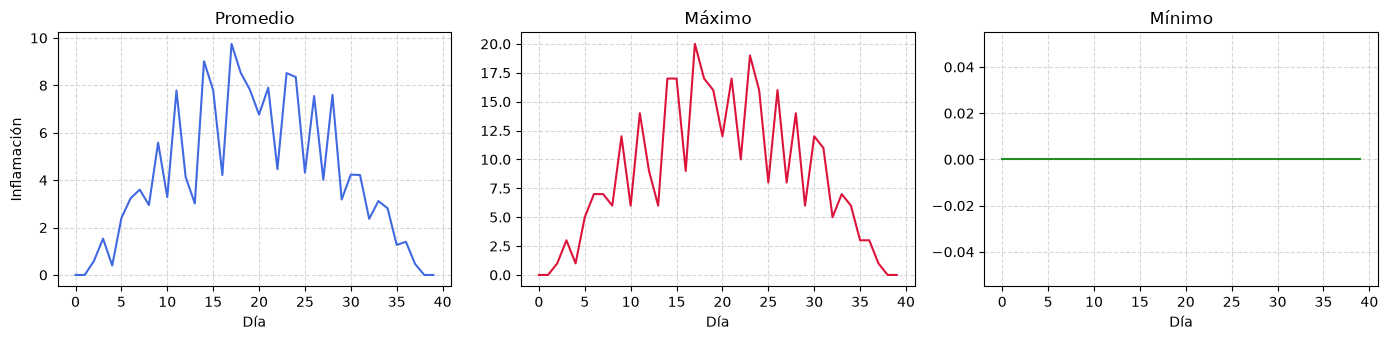

In [30]:
# 1. Obtener la lista ordenada de archivos
archivos = sorted(glob.glob('data/inflammation-*.csv'))
print(f'Total de archivos encontrados: {len(archivos)}')

# 2. Procesar los primeros 3 archivos con el bucle for
for f in archivos[:3]:
    analizar(f)

### 8. Verificación Rigurosa de Linealidad con `np.diff()`
En lugar de evaluar únicamente dos puntos discretos (día 0 y día 20), calculamos la tasa de cambio diaria (derivada discreta) para demostrar matemáticamente que la rampa es artificial.

In [ ]:
# Cargar inflammation-01.csv
data_01 = np.loadtxt(fname='data/inflammation-01.csv', delimiter=',')
max_01 = np.max(data_01, axis=0)

# Calcular diferencias consecutivas de los primeros 20 días
diferencias_primeros_20 = np.diff(max_01[:21])
print('Diferencias consecutivas (días 0 a 20):', diferencias_primeros_20)

# Comprobar si todas las diferencias son exactamente 1.0
es_lineal_perfecta = np.all(diferencias_primeros_20 == 1.0)
print(f'¿Es una rampa matemática exacta con pendiente 1.0?: {es_lineal_perfecta}')

### 9. Conclusiones Científicas y Técnicas

1. **Arquitectura en Memoria:** Los arrays de NumPy (`ndarray`) almacenan datos homogéneos en bloques continuos de memoria C, permitiendo vectorización y operaciones sin bucles explícitos.
2. **Manipulación Multidimensional:** La sintaxis `data[filas, columnas]` y el parámetro `axis` (`axis=0` colapsa pacientes verticalmente; `axis=1` colapsa días horizontalmente) proporcionan control total sobre agregaciones estadísticas.
3. **Auditoría Forense de Datos:** La combinación de visualizaciones técnicas (grilla, pasos calibrados y subplots) junto con inspección algorítmica (`np.diff`, `np.sum`) permitió clasificar los datasets en dos anomalías principales: rampa lineal artificial (`inflammation-01`, `02`) y sensor en cero constante (`inflammation-03`).
4. **Automatización:** La librería `glob` y el diseño modular mediante funciones (`analizar`, `detectar_anomalias`) permiten escalar el procesamiento a cualquier volumen de archivos de manera reproducible.